In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('../data/cleaned/ipo_cleaned.csv')
print("df Shape :",df.shape)
print("Listing gain Nulls :",df['Listing Gain'].isnull().sum())
print("Cureent Gain nulls :",df['Current Gains'].isnull().sum()) 
print("Listing Gain Stats :",df['Listing Gain'].describe().round(2))
print("Current Gains Stats :",df['Current Gains'].describe().round(2))

df Shape : (549, 19)
Listing gain Nulls : 0
Cureent Gain nulls : 0
Listing Gain Stats : count    549.00
mean      18.26
std       32.20
min      -31.73
25%        0.00
50%        7.15
75%       26.86
max      252.76
Name: Listing Gain, dtype: float64
Current Gains Stats : count     549.00
mean       88.32
std       263.96
min       -99.93
25%       -32.79
50%        15.46
75%       117.57
max      2523.67
Name: Current Gains, dtype: float64


In [9]:
corr = df['Listing Gain'].corr(df['Current Gains'])
print(f"Listing Gain vs Current Gains correlation: {corr:.4f}")
strong_listing = df[df['Listing Gain'] > 20]
strong_listing_also_long = (strong_listing['Current Gains'] > 20).sum()
total_strong = len(strong_listing)
print(f"\nIPOs with Listing Gain > 20%: {total_strong}")
print(f"Of those, also have Current Gains > 20%: {strong_listing_also_long}")
print(f"Percentage: {strong_listing_also_long/total_strong*100:.1f}%")

Listing Gain vs Current Gains correlation: 0.0700

IPOs with Listing Gain > 20%: 172
Of those, also have Current Gains > 20%: 106
Percentage: 61.6%


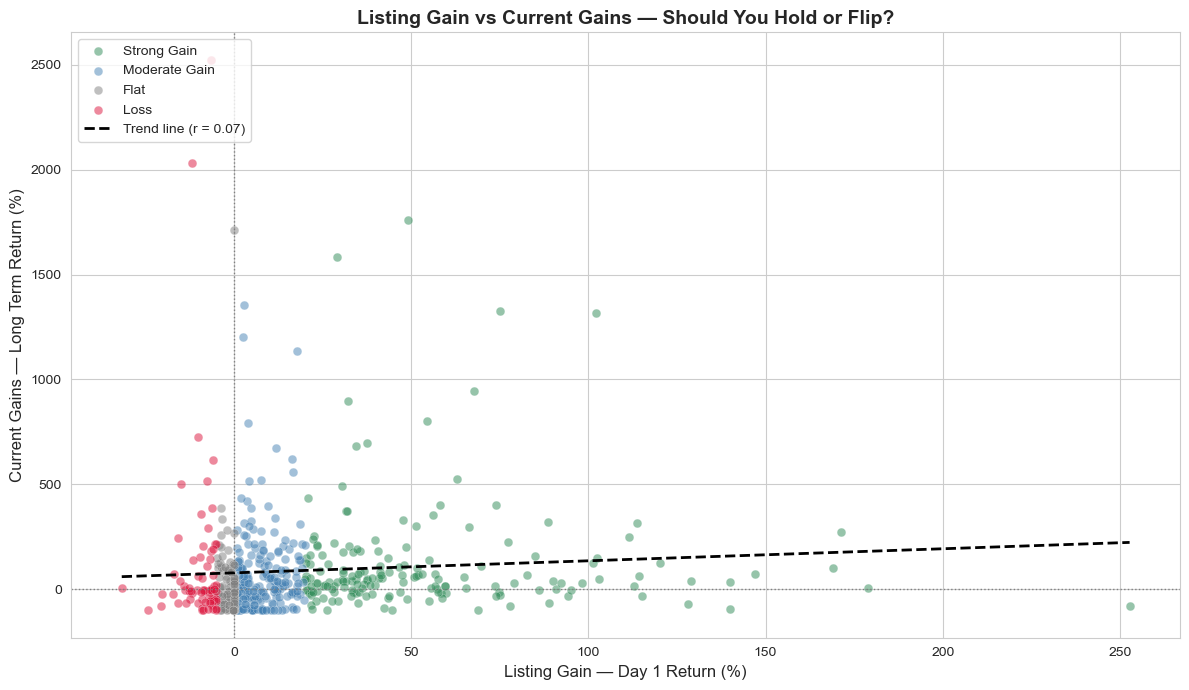

Chart saved.


In [10]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

fig, ax = plt.subplots()
# Color dots by Listing_Category for extra insight
colors_map = {
    'Strong Gain'   : 'seagreen',
    'Moderate Gain' : 'steelblue',
    'Flat'          : 'gray',
    'Loss'          : 'crimson'
}
for category, color in colors_map.items():
    subset = df[df['Listing_Category'] == category]
    ax.scatter(
        subset['Listing Gain'],
        subset['Current Gains'],
        alpha=0.5,
        color=color,
        edgecolors='white',
        linewidths=0.3,
        s=40,
        label=category
    )
z = np.polyfit(df['Listing Gain'], df['Current Gains'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Listing Gain'].min(),
                     df['Listing Gain'].max(), 100)
ax.plot(x_line, p(x_line), color='black',
        linewidth=2, linestyle='--',
        label=f'Trend line (r = {corr:.2f})')
ax.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1)

ax.set_title('Listing Gain vs Current Gains — Should You Hold or Flip?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Listing Gain — Day 1 Return (%)', fontsize=12)
ax.set_ylabel('Current Gains — Long Term Return (%)', fontsize=12)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../charts/09_listing_vs_current_gains.png', dpi=150)
plt.show()
print("Chart saved.")

In [11]:
# Compare: if you sold on listing day vs holding till today
# For IPOs that were profitable on listing day
profitable_ipos = df[df['Listing Gain'] > 0].copy()

avg_listing_if_sold    = profitable_ipos['Listing Gain'].mean()
avg_current_if_held    = profitable_ipos['Current Gains'].mean()

print(f"For IPOs profitable on listing day ({len(profitable_ipos)} IPOs):")
print(f"Avg gain if you SOLD on listing day:  {avg_listing_if_sold:.2f}%")
print(f"Avg gain if you HELD till today:       {avg_current_if_held:.2f}%")

# For IPOs that were a loss on listing day
loss_ipos = df[df['Listing Gain'] < 0].copy()
avg_current_loss_held = loss_ipos['Current Gains'].mean()

print(f"\nFor IPOs that were LOSS on listing day ({len(loss_ipos)} IPOs):")
print(f"Avg Current Gains if held till today: {avg_current_loss_held:.2f}%")
print(f"Did holding recover losses on average? {'Yes' if avg_current_loss_held > 0 else 'No'}")

For IPOs profitable on listing day (381 IPOs):
Avg gain if you SOLD on listing day:  28.55%
Avg gain if you HELD till today:       96.48%

For IPOs that were LOSS on listing day (137 IPOs):
Avg Current Gains if held till today: 74.07%
Did holding recover losses on average? Yes


In [ ]:
Correlation between Listing Gain and Current Gains: 0.07
This is almost zero — listing day performance has 
virtually no relationship with long term returns.

The scatter plot confirms this visually — dots are 
spread all over the chart with no clear direction.
Red dots (Loss on listing day) appear at the top 
of the Y axis with 2000%+ long term returns.
This means some IPOs that flopped on Day 1 became 
massive long term winners.

Hold vs Flip comparison:
- Sold on listing day: avg 28.55% gain
- Held till today: avg 96.48% gain
Holding gave 3.4x more return than flipping.

Even IPOs that were a loss on listing day gave 
74.07% average return if held long term.
The market corrects itself — a bad listing day 
does not mean a bad company.

Key insight: Listing gain is a short term signal.
Current gain is driven by business fundamentals.
These are two completely different questions.